# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Loading data

https://www.kaggle.com/datasets/denkuznetz/taxi-price-prediction/data

In [3]:
src = 'taxi_trip_pricing.csv'
data = pd.read_csv(src)

In [4]:
data.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [6]:
# for column in data.columns:
#     print(f'unique values of {column}:\n {data[column].unique()}\n---------------------------------------------------------')

In [7]:
data.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [8]:
data.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [9]:
data.Time_of_Day.unique()

array(['Morning', 'Afternoon', 'Evening', 'Night', nan], dtype=object)

In [10]:
data.Day_of_Week.unique()


array(['Weekday', 'Weekend', nan], dtype=object)

In [11]:
data.Traffic_Conditions.unique()

array(['Low', 'High', 'Medium', nan], dtype=object)

In [12]:
data.Weather.unique()


array(['Clear', nan, 'Rain', 'Snow'], dtype=object)

In [13]:
data.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [14]:
data.sample(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
43,45.56,Afternoon,Weekday,NaN,Low,Clear,NaN,0.90,0.50,80.80,85.8840
832,7.90,Afternoon,Weekday,3.0,Medium,Clear,3.61,1.91,0.42,55.74,42.1098
920,43.55,Afternoon,Weekday,2.0,Low,NaN,4.97,0.79,0.33,111.30,NaN
621,11.26,Morning,Weekend,3.0,Medium,Rain,2.34,0.68,NaN,58.80,30.5768
784,9.90,Afternoon,Weekend,3.0,Medium,Clear,2.62,0.81,0.34,102.33,45.4312
371,1.89,Morning,Weekend,1.0,Low,Clear,2.71,0.62,0.11,20.41,6.1269
515,2.29,Morning,Weekend,1.0,Low,Clear,4.26,1.80,0.41,13.54,13.9334
447,37.92,Evening,Weekday,2.0,Medium,Rain,2.02,0.84,0.39,112.04,77.5684
545,18.55,Afternoon,Weekday,1.0,Medium,Clear,4.28,1.07,0.14,NaN,25.3115
150,45.51,Evening,Weekday,1.0,Medium,Clear,4.23,0.63,0.13,27.65,36.4958


In [17]:
# data.mode()

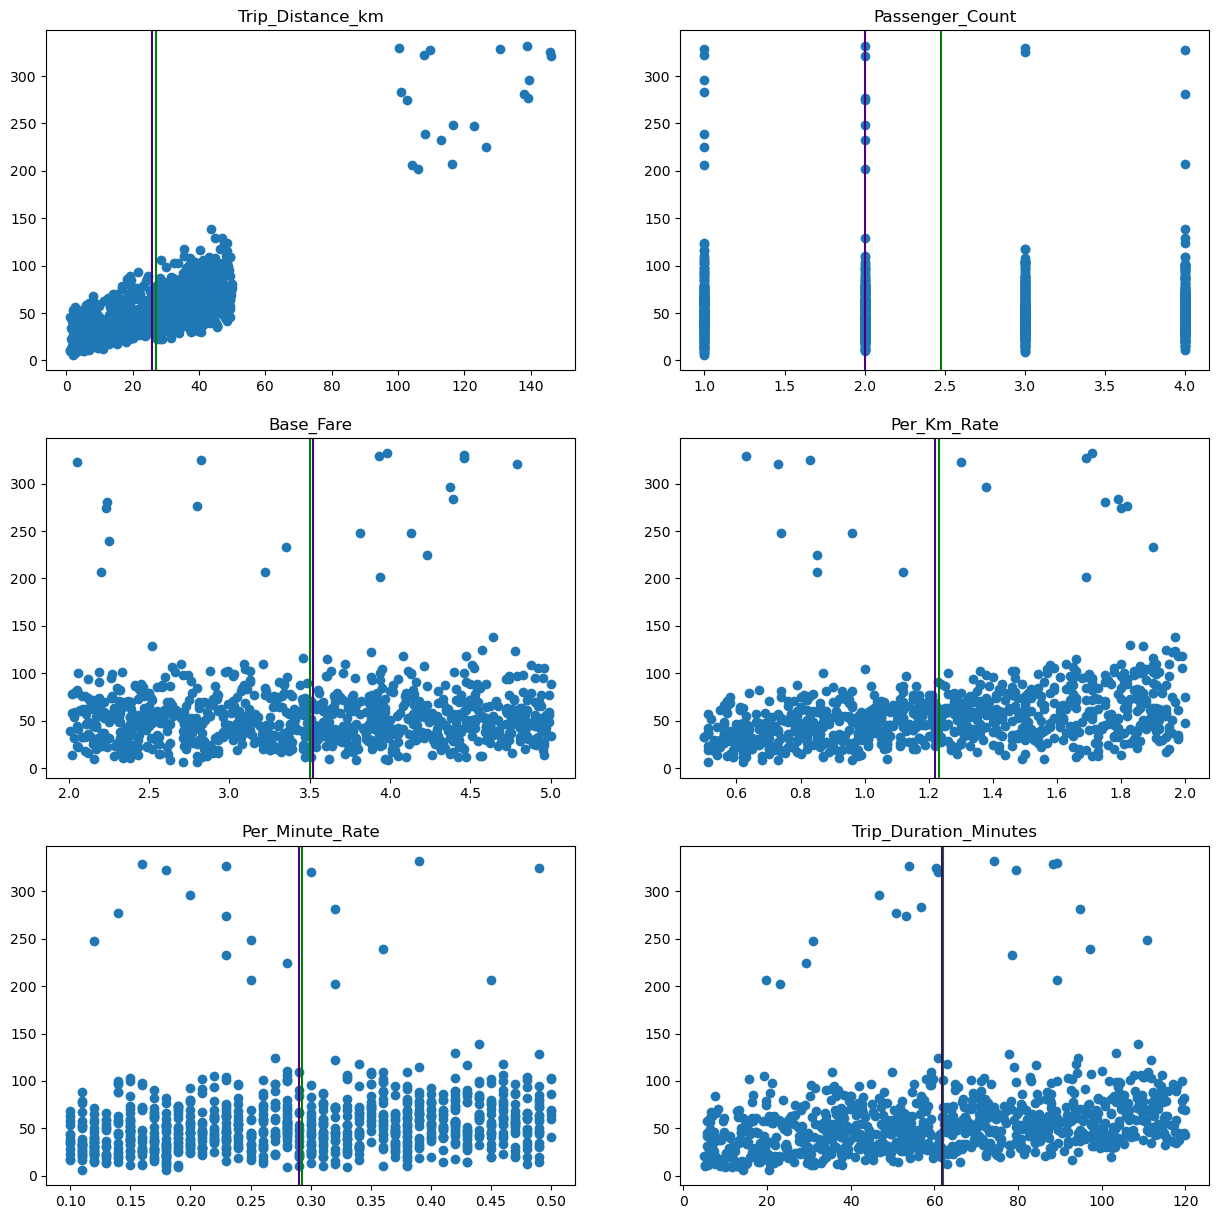

In [16]:
cols = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes']

figure, ax = plt.subplots(3, 2, figsize=[15,15])

for i in range(3):
    for j in range(2):
        index = cols[i*2+j]
        ax[i, j].scatter(data[index], data['Trip_Price'])
        ax[i, j].title.set_text(index)
        ax[i, j].axvline(data[index].mean(), color='green')
        ax[i, j].axvline(data[index].median(), color='indigo')
        # ax[i, j].axvline(data[index].mode())       

In [20]:
data.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [25]:
data['predict'] = data.Base_Fare + data.Per_Minute_Rate * data.Trip_Duration_Minutes + data.Per_Km_Rate * data.Trip_Distance_km
data.loc[:, ['predict', 'Trip_Price']]

,predict,Trip_Price
0,36.2624,36.2624
1,NaN,NaN
2,52.9032,52.9032
3,36.4698,36.4698
4,NaN,15.6180
...,...,...
995,34.4049,34.4049
996,NaN,62.1295
997,NaN,33.1236
998,61.2090,61.2090


In [28]:
accuracy = data['predict'] == data['Trip_Price']
accuracy.sum()

526

In [38]:
valid = data['predict'].notnull()
data['predict'].notnull().sum()


766

In [39]:
accuracy = data['predict'] != data['Trip_Price']
accuracy.sum()

474

In [40]:
data.loc[accuracy & valid]

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,predict
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028,60.2028
8,30.45,Morning,Weekday,3.0,High,Clear,2.77,1.78,0.34,110.33,NaN,94.4832
12,41.79,Night,Weekend,3.0,High,Clear,4.60,1.77,0.11,86.95,88.1328,88.1328
15,9.99,Night,Weekday,4.0,High,Clear,4.33,0.85,0.43,34.00,27.4415,27.4415
16,15.91,Morning,Weekday,4.0,Low,Clear,4.42,1.77,0.21,114.93,56.7160,56.7160
...,...,...,...,...,...,...,...,...,...,...,...,...
982,6.22,Afternoon,Weekend,4.0,Medium,Clear,3.87,1.16,0.47,75.63,46.6313,46.6313
983,4.68,Afternoon,Weekend,4.0,Medium,Rain,2.03,1.24,0.47,97.50,53.6582,53.6582
990,40.17,Evening,Weekday,3.0,Low,Clear,3.81,0.66,0.42,62.66,56.6394,56.6394
991,35.04,Morning,Weekend,4.0,Medium,Rain,2.90,1.10,0.15,9.99,NaN,42.9425
